In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-supply-chain-risk-and-logistics-2024-2026/global_supply_chain_risk_2026.csv


<div style="padding:20px; border-radius:10px; background-color:#1a5276; color:white; text-align:center;">
    <h1 style="font-family: 'Verdana';"> Global Supply Chain Risk Analysis</h1>
    <p style="font-size:16px;">Predicting Disruptions and Lead-Time Volatility in 2026</p>
</div>

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Using OS to find the file path
for dirname, _, filenames in os.walk('/kaggle/input/'):
    for filename in filenames:
        path = os.path.join(dirname, filename)
        print(f"File found: {path}")

# Load the data
df = pd.read_csv(path)
sns.set_style("whitegrid")

File found: /kaggle/input/global-supply-chain-risk-and-logistics-2024-2026/global_supply_chain_risk_2026.csv


<div style="border-left: 8px solid #1a5276; padding: 10px; background-color: #f4f6f7; margin-top: 20px;">
    <h2 style="color: #1a5276;">1. Data Overview & Integrity</h2>
    <p>We check for missing values and examine the distribution of our target variables.</p>
</div>

In [3]:
print(f"Dataset Shape: {df.shape}")
df.info()
display(df.describe().T)

Dataset Shape: (5000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   object 
 1   Date                       5000 non-null   object 
 2   Origin_Port                5000 non-null   object 
 3   Destination_Port           5000 non-null   object 
 4   Transport_Mode             5000 non-null   object 
 5   Product_Category           5000 non-null   object 
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   object 
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred   

,count,mean,std,min,25%,50%,75%,max
Distance_km,5000.0,7704.063888,4199.687885,500.17,4036.010,7750.125,11347.4625,14995.91
Weight_MT,5000.0,246.252052,142.522591,1.03,124.330,243.500,366.9550,499.75
Fuel_Price_Index,5000.0,2.854552,0.959533,1.20,2.020,2.840,3.7100,4.50
Geopolitical_Risk_Score,5000.0,5.076900,2.877832,0.00,2.600,5.100,7.5000,10.00
Carrier_Reliability_Score,5000.0,0.754387,0.144363,0.50,0.629,0.757,0.8790,1.00
Lead_Time_Days,5000.0,19.355386,31.405143,0.50,2.110,8.245,21.2075,236.39
Disruption_Occurred,5000.0,0.612600,0.487205,0.00,0.000,1.000,1.0000,1.00


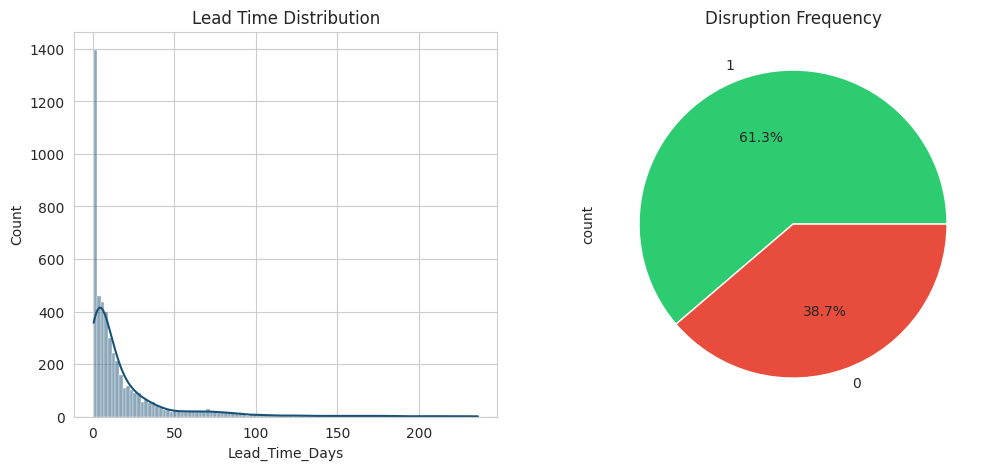

In [4]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Lead_Time_Days'], kde=True, color='#1a5276')
plt.title('Lead Time Distribution')

plt.subplot(1, 2, 2)
df['Disruption_Occurred'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
plt.title('Disruption Frequency')
plt.show()

<div style="border-left: 8px solid #e67e22; padding: 10px; background-color: #fef5e7; margin-top: 20px;">
    <h2 style="color: #e67e22;">2. Geopolitical & Weather Correlations</h2>
    <p>Analyzing how external risk factors drive shipment delays.</p>
</div>

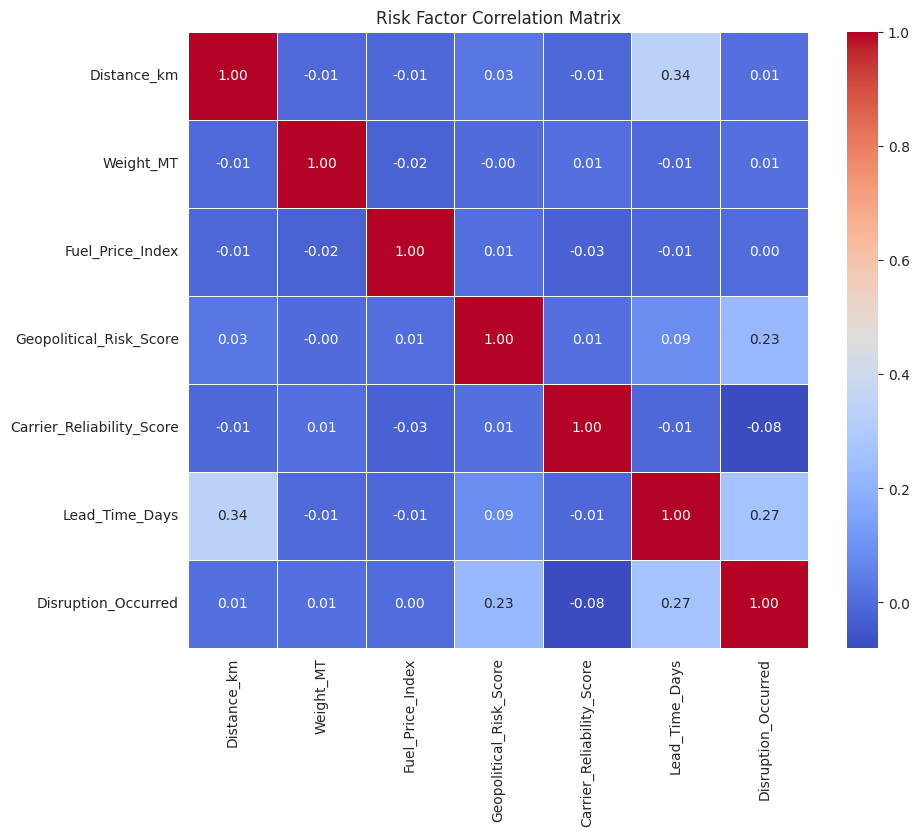

In [5]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Risk Factor Correlation Matrix')
plt.show()

/tmp/ipykernel_17/3955879928.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Weather_Condition', y='Lead_Time_Days', data=df, palette='viridis')


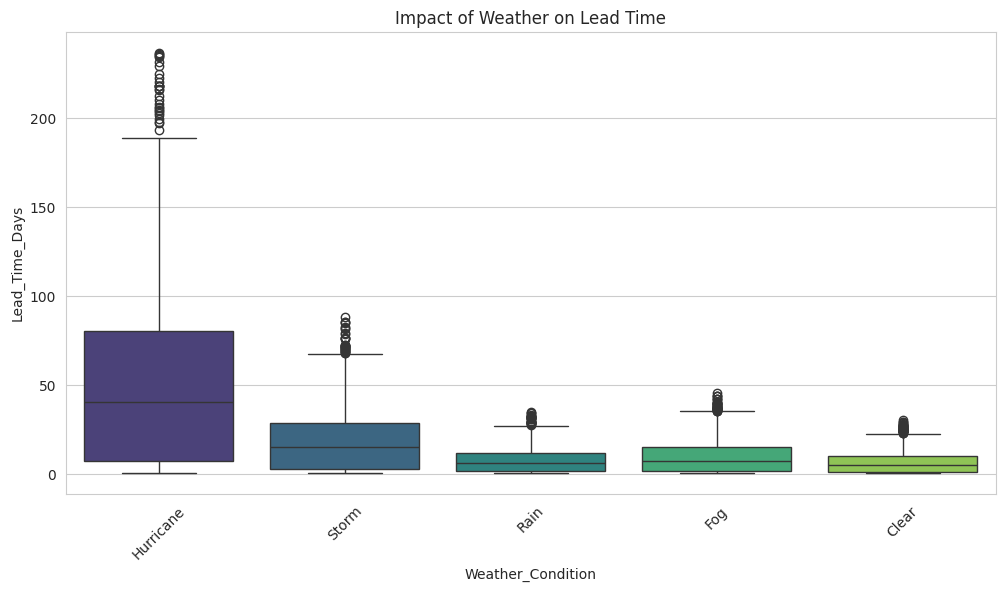

In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Weather_Condition', y='Lead_Time_Days', data=df, palette='viridis')
plt.title('Impact of Weather on Lead Time')
plt.xticks(rotation=45)
plt.show()

<div style="border-left: 8px solid #27ae60; padding: 10px; background-color: #eafaf1; margin-top: 20px;">
    <h2 style="color: #27ae60;">3. Feature Engineering for Predictive Modeling</h2>
    <p>Creating categorical encodings to prepare for the XGBoost model.</p>
</div>

In [7]:
from sklearn.preprocessing import LabelEncoder

# Encoding categorical variables
le = LabelEncoder()
cat_cols = ['Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category', 'Weather_Condition']

df_ml = df.copy()
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

print("Encoding complete.")

Encoding complete.


In [8]:
X = df_ml.drop(['Shipment_ID', 'Date', 'Disruption_Occurred', 'Lead_Time_Days'], axis=1)
y = df_ml['Disruption_Occurred']

print(f"Features: {list(X.columns)}")

Features: ['Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category', 'Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Weather_Condition', 'Carrier_Reliability_Score']


<div style="border-left: 8px solid #c0392b; padding: 10px; background-color: #f9ebea; margin-top: 20px;">
    <h2 style="color: #c0392b;">4. Model Training & Next Steps</h2>
    <p>We split the data and identify the core predictors of supply chain failure.</p>
</div>

In [9]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(n_estimators=100, learning_rate=0.1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.67      0.65       379
           1       0.79      0.76      0.78       621

    accuracy                           0.73      1000
   macro avg       0.71      0.72      0.72      1000
weighted avg       0.73      0.73      0.73      1000



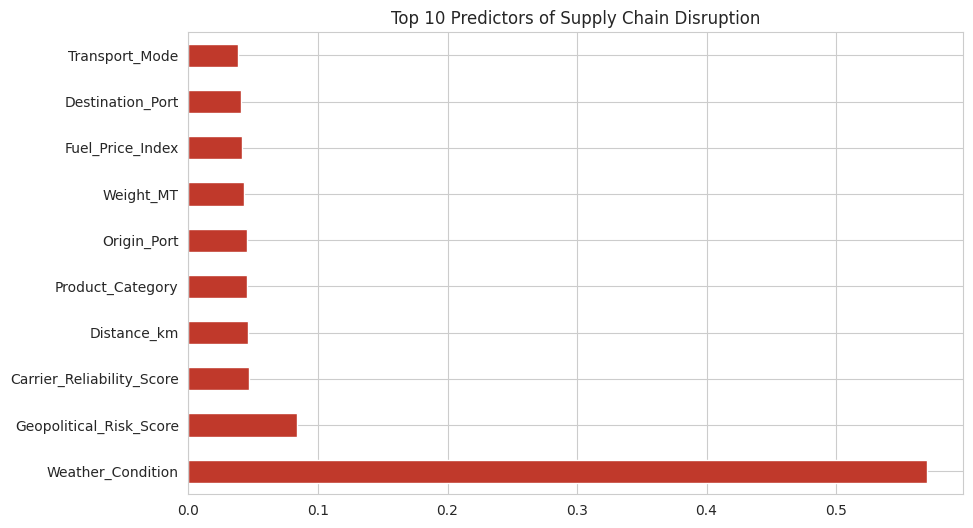

In [10]:
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='#c0392b')
plt.title('Top 10 Predictors of Supply Chain Disruption')
plt.show()